# Partially-Observed Planning from Pixels with JaxPlan

In this notebook, we use image segmentation to plan from pixels in JaxPlan. The pong domain is used as illustrative example.

## State Inference using Image Segmentation from Pong Pixels

Install the required packages:

In [ ]:
%pip install --quiet --upgrade pip
%pip install --quiet opencv-python pyRDDLGym rddlrepository pyRDDLgym-jax

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import the required packages:

In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import matplotlib.pyplot as plt
from IPython.display import Image
import cv2
import numpy as np

import pyRDDLGym
from pyRDDLGym.core.policy import RandomAgent
from pyRDDLGym.core.visualizer.movie import MovieGenerator
from pyRDDLGym_jax.core.planner import JaxBackpropPlanner, JaxOnlineController, load_config_from_string

We use image segmentation to identify the ball (x, y) coordinates and the paddle y-coordinate from the frame.

In [2]:
def segment_frame(img):
    img_rgb = np.array(img)

    # detect ball using red color channel
    r, g = img_rgb[:, :, 0].astype(int), img_rgb[:, :, 1].astype(int)
    red_mask = (r - g > 80) & (r > 150)
    red_u8 = red_mask.astype(np.uint8) * 255
    bx = by = bw = bh = np.nan
    for cnt in cv2.findContours(red_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]:
        if cv2.contourArea(cnt) > 5:
            bx, by, bw, bh = cv2.boundingRect(cnt); break
    
    # detect paddle by counting black pixels per row
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray[red_mask] = 255
    row_count = cv2.threshold(gray, 50, 1, cv2.THRESH_BINARY_INV)[1].sum(axis=1)
    paddle_rows = np.where((row_count > 4) & (row_count < 10))[0]
    py = np.min(paddle_rows)
    ph = np.max(paddle_rows) - py
    
    # convert paddle start and end to board height by assuming symmetric borders
    border_start = np.argmax(row_count)
    board_height = img_rgb.shape[0] - 2 * border_start
    paddle_y = 1 - float((py - border_start) / board_height) - float(ph / board_height)
    ball_x = float((bx - border_start) / board_height)
    ball_y = 1 - float((by - border_start) / board_height)
    
    # visualize segmentation results
    px = img_rgb.shape[1] - border_start
    if not np.isnan(bx):
        cv2.rectangle(img_rgb, (bx, by), (bx + bw, by + bh), (0, 0, 255), 2)
    cv2.rectangle(img_rgb, (px, py), (px + 6, py + ph), (0, 255, 0), 2)
    
    return ball_x, ball_y, paddle_y, img_rgb

Let's test this on some frames from the Pong environment:

pred ball_x: 0.49 vs test 0.50, pred ball_y: 0.52 vs test 0.50, pred paddle_y: 0.39 vs test 0.40
pred ball_x: 0.52 vs test 0.53, pred ball_y: 0.53 vs test 0.51, pred paddle_y: 0.44 vs test 0.44
pred ball_x: 0.56 vs test 0.56, pred ball_y: 0.54 vs test 0.52, pred paddle_y: 0.48 vs test 0.48
pred ball_x: 0.59 vs test 0.59, pred ball_y: 0.55 vs test 0.53, pred paddle_y: 0.44 vs test 0.44
pred ball_x: 0.62 vs test 0.62, pred ball_y: 0.56 vs test 0.54, pred paddle_y: 0.44 vs test 0.44
pred ball_x: 0.64 vs test 0.65, pred ball_y: 0.57 vs test 0.55, pred paddle_y: 0.48 vs test 0.48
pred ball_x: 0.68 vs test 0.68, pred ball_y: 0.58 vs test 0.56, pred paddle_y: 0.48 vs test 0.48
pred ball_x: 0.71 vs test 0.71, pred ball_y: 0.59 vs test 0.57, pred paddle_y: 0.52 vs test 0.52
pred ball_x: 0.74 vs test 0.74, pred ball_y: 0.60 vs test 0.58, pred paddle_y: 0.48 vs test 0.48
pred ball_x: 0.77 vs test 0.77, pred ball_y: 0.61 vs test 0.59, pred paddle_y: 0.52 vs test 0.52
pred ball_x: 0.80 vs test 0.80

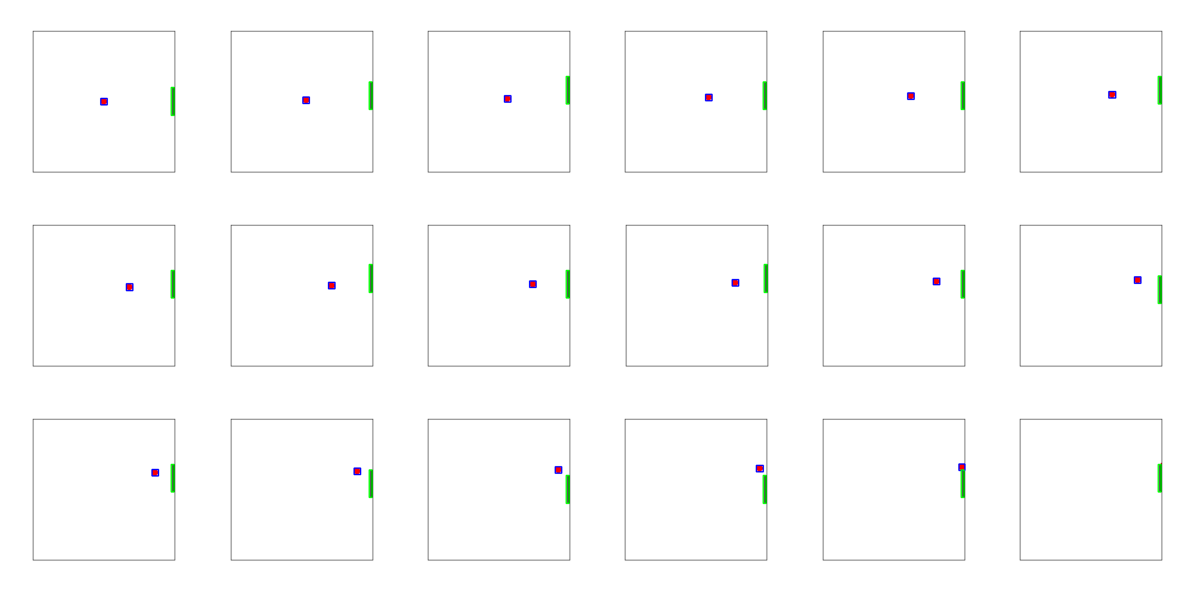

In [3]:
# generate some frames from a random policy, compare segmentation state to true states
env = pyRDDLGym.make('Pong_arcade', '0')
agent = RandomAgent(env.action_space)
frames = []
state, _ = env.reset()
for step in range(18):
    ball_x, ball_y, paddle_y, img_rgb = segment_frame(env.render(False))
    print(f"pred ball_x: {ball_x:.2f} vs test {state['ball-x___b1']:.2f}, "
          f"pred ball_y: {ball_y:.2f} vs test {state['ball-y___b1']:.2f}, "
          f"pred paddle_y: {paddle_y:.2f} vs test {state['paddle-y']:.2f}")
    frames.append(img_rgb)
    action = agent.sample_action(state)
    state, *_ = env.step(action)
env.close()
plt.close('all')

# plot segmented frames
%matplotlib inline
fig, axs = plt.subplots(ncols=6, nrows=3, figsize=(12, 6))
for fr, ax in zip(frames, axs.flatten()):
    ax.imshow(fr); ax.axis('off')
plt.tight_layout(); plt.show()

We also need to infer the ball velocities. To do this, we need two consecutive frames (we also vectorize the state for the planner):

In [4]:
def extract_state(prev_obs, next_obs):
    ball_x1, ball_y1, *_ = segment_frame(prev_obs)
    ball_x2, ball_y2, paddle_y, _ = segment_frame(next_obs)
    return {
        'ball-x': np.array([ball_x2]), 
        'ball-y': np.array([ball_y2]), 
        'vel-x': np.array([ball_x2 - ball_x1]), 
        'vel-y': np.array([ball_y2 - ball_y1]), 
        'paddle-y': paddle_y
    }

## Control from Pixels with JaxPlan

Let's initialize and run the MPC controller in JaxPlan. We map pairs of consecutive images to states and run JaxPlan from these inferred states:

In [8]:
config_str = """
[Compiler]
print_warnings=False
[Planner]
method='JaxStraightLinePlan'
optimizer_kwargs={'learning_rate': 0.01}
batch_size_train=16
batch_size_test=16
rollout_horizon=40
[Optimize]
key=42
epochs=200
"""
planner_args, _, train_args = load_config_from_string(config_str)
planner = JaxBackpropPlanner(rddl=env.model, **planner_args)
agent = JaxOnlineController(planner, print_summary=False, print_progress=False, **train_args)

Let's run the controller:

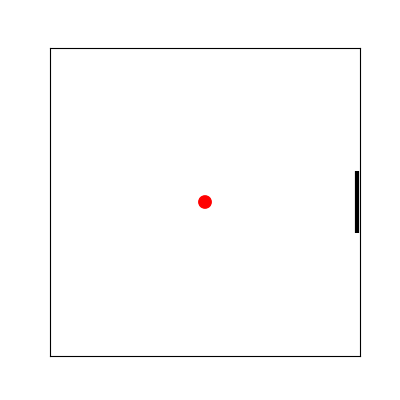

In [10]:
# set visualizer
if not os.path.exists('frames'):
    os.makedirs('frames')
env = pyRDDLGym.make('Pong_arcade', '0', vectorized=True)
recorder = MovieGenerator("frames", "pong_pomdp", max_frames=150)
env.set_visualizer(viz=None, movie_gen=recorder)

# run control
env.reset(seed=0)
prev_obs = env.render()
for step in range(150):
    obs = env.render()
    state_pred = extract_state(prev_obs, obs)
    action = agent.sample_action(state_pred)
    env.step(action)
    prev_obs = obs
env.close()
plt.close('all')
Image(filename='frames/pong_pomdp_0.gif') 